# Descrição do Dataset: [Spaceship Titanic](https://www.kaggle.com/competitions/spaceship-titanic/data)

O dataset utilizado nesta competição é uma versão derivativa e sintética que simula um cenário de ficção científica: o objetivo é prever se um passageiro foi transportado para uma dimensão alternativa após a colisão da nave ***Spaceship Titanic*** com uma anomalia espaço-temporal.

Para construir as previsões, o conjunto de dados fornece registros pessoais recuperados do sistema de computadores danificado da nave.

## Arquivos do Projeto

* **`train.csv`**: Registros pessoais de aproximadamente dois terços (~8.700) dos passageiros, utilizados como dados de treino. Contém a variável alvo (`Transported`).
* **`test.csv`**: Registros pessoais do terço restante (~4.300) dos passageiros, utilizados como dados de teste. O objetivo é prever o valor de `Transported` para este conjunto.

---

## Dicionário de Dados (Variáveis)

O conjunto de dados possui as seguintes colunas informativas:

## Identificação e Perfil do Passageiro

* **`PassengerId`**: Um identificador único para cada passageiro no formato `gggg_pp`, onde:
* `gggg` indica o grupo com o qual o passageiro está viajando (frequentemente membros da mesma família).
* `pp` é o número do passageiro dentro daquele grupo.

* **`Name`**: O nome e sobrenome do passageiro.
* **`Age`**: A idade do passageiro.

## Detalhes da Viagem

* **`HomePlanet`**: O planeta de origem do passageiro.
* **`Destination`**: O planeta de destino onde o passageiro iria desembarcar.
* **`Cabin`**: O número da cabine onde o passageiro estava hospedado. Segue o formato `deck/num/side` (conves/número/lado), onde o lado pode ser **P** (*Port* - Bombordo) ou **S** (*Starboard* - Estibordo).
* **`CryoSleep`**: Indica se o passageiro optou por ser colocado em animação suspensa (criossono) durante a viagem. Passageiros em criossono ficam confinados em suas cabines.
* **`VIP`**: Indica se o passageiro pagou por serviços VIP especiais durante a viagem.

## Despesas a Bordo

Valor total que o passageiro gastou em cada uma das muitas comodidades de luxo da Spaceship Titanic:

* **`RoomService`**: Serviço de quarto.
* **`FoodCourt`**: Praça de alimentação.
* **`ShoppingMall`**: Shopping center.
* **`Spa`**: Centro de relaxamento/Spa.
* **`VRDeck`**: Deck de Realidade Virtual.

## Variável Alvo (*Target*)

* **`Transported`**: Indica se o passageiro foi transportado para outra dimensão (**True** ou **False**). Esta é a variável que o modelo deve prever.

# *Setup* do ambiente

Nessa seção iremos:
- Baixar as bibliotecas necessárias no projeto;
- Definir configurações globais de bibliotecas;
- Baixar o dataset.

In [ ]:
# Manipulação básica de dados
import pandas as pd

# Bibliotecas de visualização e utilitários usados nas células de EDA abaixo
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e modelagem
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

# Plot da arvore de decisao (metodo do scikit-learn)
from matplotlib_inline.backend_inline import set_matplotlib_formats
from sklearn import tree

# Estilo consistente para todos os gráficos
sns.set_theme(style="whitegrid")

In [127]:
train = pd.read_csv("./data/train.csv")
test = pd.read_csv("./data/test.csv")

print("Tabela com as primeiras linhas do conjunto de treino")

# Visualização rápida das primeiras linhas
train.head()

Tabela com as primeiras linhas do conjunto de treino


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


# Análise Exploratória dos Dados (EDA)

Nesta seção, iremos explorar a estrutura do conjunto de treino, a qualidade dos dados e os principais padrões associados ao alvo `Transported`.
Antes de analisar relações e correlações, faremos uma etapa pontual de pré-processamento para separar `PassengerId` em `PassengerGroup` e `PassengerNum` e `Cabin` em `CabinDeck` e `CabinSide`.
Vamos aplicar esse passo tanto no conjunto de treino quanto no conjunto de teste, mas sem substituir os dados originais; usaremos uma cópia apenas para a EDA.
Deixamos a alteração do `train` e do `test` para a seção de pré-processamento, como parte do pipeline de modelagem.


In [128]:
# Pré-processamento pontual para simplificar a EDA (treino e teste)
def split_cabin_passenger(df):
    out = df.copy()

    passenger_parts = out["PassengerId"].str.split("_", expand=True)
    out["PassengerGroup"] = passenger_parts[0]
    out["PassengerNum"] = pd.to_numeric(passenger_parts[1], errors="coerce")

    cabin_parts = out["Cabin"].str.split("/", expand=True)
    out["CabinDeck"] = cabin_parts[0]
    out["CabinSide"] = cabin_parts[2]

    out = out.drop(columns=["PassengerId", "Cabin"])
    return out

eda = split_cabin_passenger(train)
_ = split_cabin_passenger(test)

In [129]:
# Visão geral do dataset: tipos, contagens de não nulos e memória
print("Resumo do dataset com tipos e contagem de valores não nulos")
eda.info()

Resumo do dataset com tipos e contagem de valores não nulos
<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   HomePlanet      8492 non-null   str    
 1   CryoSleep       8476 non-null   object 
 2   Destination     8511 non-null   str    
 3   Age             8514 non-null   float64
 4   VIP             8490 non-null   object 
 5   RoomService     8512 non-null   float64
 6   FoodCourt       8510 non-null   float64
 7   ShoppingMall    8485 non-null   float64
 8   Spa             8510 non-null   float64
 9   VRDeck          8505 non-null   float64
 10  Name            8493 non-null   str    
 11  Transported     8693 non-null   bool   
 12  PassengerGroup  8693 non-null   str    
 13  PassengerNum    8693 non-null   int64  
 14  CabinDeck       8494 non-null   str    
 15  CabinSide       8494 non-null   str    
dtypes: bool(1), float64(6), int64

In [130]:
# Descrição geral dos atributos numéricos
print("Tabela com estatísticas descritivas das variáveis numéricas")
eda.describe()

Tabela com estatísticas descritivas das variáveis numéricas


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,PassengerNum
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000,8693.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791,1.517773
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189,1.054241
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000,2.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000,8.000000


In [131]:
# Percentual de gasto zero por serviço
print("Tabela com percentual de gasto zero por serviço")
(eda[["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]] == 0).mean() * 100

Tabela com percentual de gasto zero por serviço


RoomService     64.155067
FoodCourt       62.763143
ShoppingMall    64.270102
Spa             61.244680
VRDeck          63.211780
dtype: float64

In [132]:
# Função auxiliar: resumo de valores ausentes por coluna
def missing_summary(df):
    missing = df.isna().sum()
    pct = (missing / len(df) * 100).round(2)
    out = pd.DataFrame({"missing_count": missing, "missing_pct": pct})
    return out[out["missing_count"] > 0].sort_values("missing_pct", ascending=False)

In [133]:
print("Tabela com quantidade de valores ausentes e percentual por atributo")
missing_eda = missing_summary(eda)
display(missing_eda)

Tabela com quantidade de valores ausentes e percentual por atributo


,missing_count,missing_pct
CryoSleep,217,2.50
ShoppingMall,208,2.39
VIP,203,2.34
HomePlanet,201,2.31
Name,200,2.30
CabinDeck,199,2.29
CabinSide,199,2.29
VRDeck,188,2.16
FoodCourt,183,2.11
Spa,183,2.11


Gráfico com quantidade de valores ausentes por atributo


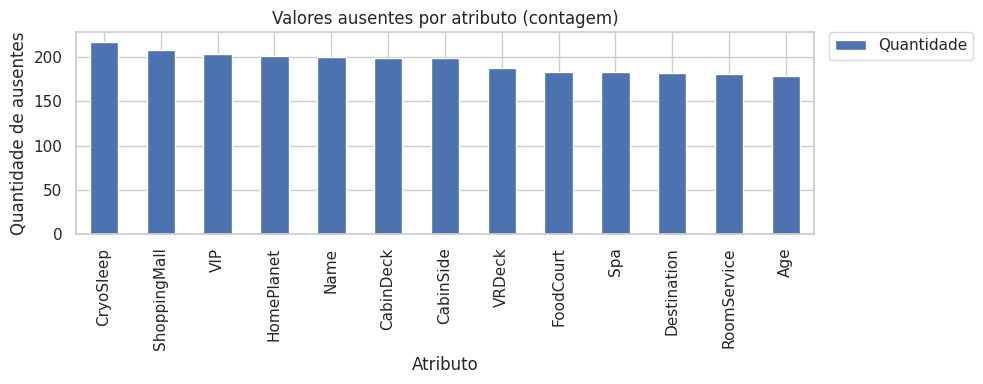

In [134]:
print("Gráfico com quantidade de valores ausentes por atributo")
ax = missing_eda["missing_count"].plot(
    kind="bar",
    figsize=(10, 4),
    title="Valores ausentes por atributo (contagem)"
)
ax.set_xlabel("Atributo")
ax.set_ylabel("Quantidade de ausentes")
ax.legend(["Quantidade"], bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

Gráfico com percentual de valores ausentes por atributo


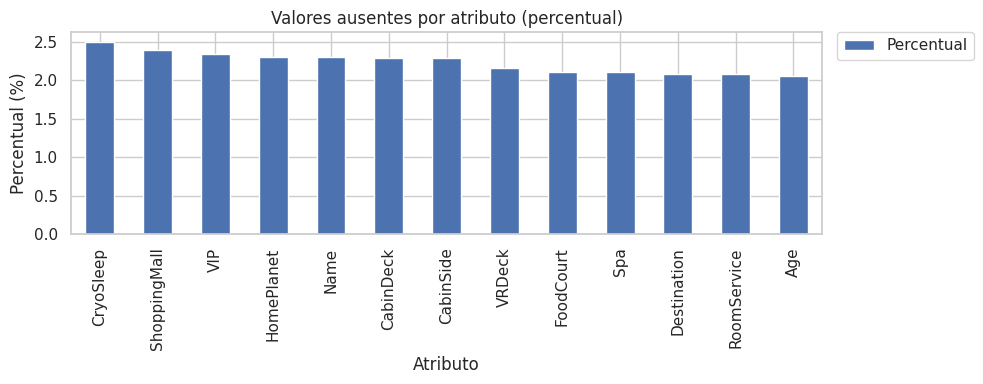

In [135]:
print("Gráfico com percentual de valores ausentes por atributo")
ax = missing_eda["missing_pct"].plot(
    kind="bar",
    figsize=(10, 4),
    title="Valores ausentes por atributo (percentual)"
)
ax.set_xlabel("Atributo")
ax.set_ylabel("Percentual (%)")
ax.legend(["Percentual"], bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

Tabela com contagem e percentual do atributo alvo


,count,pct
Transported,,
True,4378,50.36
False,4315,49.64


Gráfico com distribuição do atributo alvo


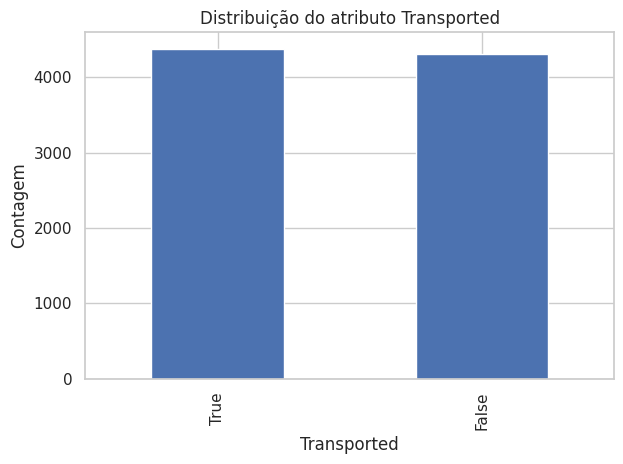

In [136]:
# Distribuição do atributo alvo para checar balanceamento de classes
print("Tabela com contagem e percentual do atributo alvo")
target_counts = eda["Transported"].value_counts(dropna=False)
target_pct = eda["Transported"].value_counts(normalize=True, dropna=False).mul(100).round(2)
display(pd.DataFrame({"count": target_counts, "pct": target_pct}))

print("Gráfico com distribuição do atributo alvo")
ax = target_counts.plot(kind="bar", title="Distribuição do atributo Transported")
ax.set_xlabel("Transported")
ax.set_ylabel("Contagem")
plt.tight_layout()
plt.show()

In [137]:
# Cardinalidade de campos categóricos para identificar alta/baixa variedade
print("Tabela com cardinalidade de atributos categóricos")
cat_cols = ["HomePlanet", "Destination", "CryoSleep", "VIP", "CabinDeck", "CabinSide"]
cardinality = eda[cat_cols].nunique().sort_values(ascending=False)
display(cardinality.to_frame("nunique"))

Tabela com cardinalidade de atributos categóricos


,nunique
CabinDeck,8
HomePlanet,3
Destination,3
CryoSleep,2
VIP,2
CabinSide,2


In [138]:
# Associacao entre PassengerGroup e HomePlanet (Cramer's V)
from scipy.stats import chi2_contingency

contingency = pd.crosstab(
    eda["PassengerGroup"],
    eda["HomePlanet"],
    dropna=False,
)
chi2 = chi2_contingency(contingency, correction=False)[0]
n = contingency.to_numpy().sum()
r, k = contingency.shape
cramers_v = np.sqrt(chi2 / (n * (min(r - 1, k - 1))))
print(f"Cramers V (PassengerGroup x HomePlanet): {cramers_v:.4f}")

group_homeplanet_counts = eda.groupby("PassengerGroup")["HomePlanet"].nunique(dropna=False)
mixed_groups = group_homeplanet_counts[group_homeplanet_counts > 1]
pct_mixed = mixed_groups.size / group_homeplanet_counts.size * 100
print(f"Grupos com mais de um HomePlanet: {mixed_groups.size} ({pct_mixed:.2f}%)")
display(mixed_groups.head(10).rename("n_homeplanet"))

Cramers V (PassengerGroup x HomePlanet): 0.9478
Grupos com mais de um HomePlanet: 89 (1.43%)


PassengerGroup
0064    2
0119    2
0444    2
0445    2
0470    2
0504    2
0539    2
0540    2
0560    2
0594    2
Name: n_homeplanet, dtype: int64

In [139]:
# Compara a taxa de transporte entre categorias principais
for col in cat_cols:
    tab = pd.crosstab(eda[col], eda["Transported"], normalize="index")
    tab = tab.rename(columns={False: "não_transportado", True: "transportado"})
    print(f"Tabela com taxa de transporte por categoria: {col}")
    display(tab.sort_values("transportado", ascending=False).round(3))

Tabela com taxa de transporte por categoria: HomePlanet


Transported,não_transportado,transportado
HomePlanet,,
Europa,0.341,0.659
Mars,0.477,0.523
Earth,0.576,0.424


Tabela com taxa de transporte por categoria: Destination


Transported,não_transportado,transportado
Destination,,
55 Cancri e,0.390,0.610
PSO J318.5-22,0.496,0.504
TRAPPIST-1e,0.529,0.471


Tabela com taxa de transporte por categoria: CryoSleep


...

Transported,não_transportado,transportado
VIP,,
False,0.494,0.506
True,0.618,0.382


Tabela com taxa de transporte por categoria: CabinDeck


Transported,não_transportado,transportado
CabinDeck,,
B,0.266,0.734
C,0.320,0.680
G,0.484,0.516
A,0.504,0.496
F,0.560,0.440
D,0.567,0.433
E,0.643,0.357
T,0.800,0.200


Tabela com taxa de transporte por categoria: CabinSide


Transported,não_transportado,transportado
CabinSide,,
S,0.445,0.555
P,0.549,0.451


Gráfico com taxa de transporte por categoria: HomePlanet


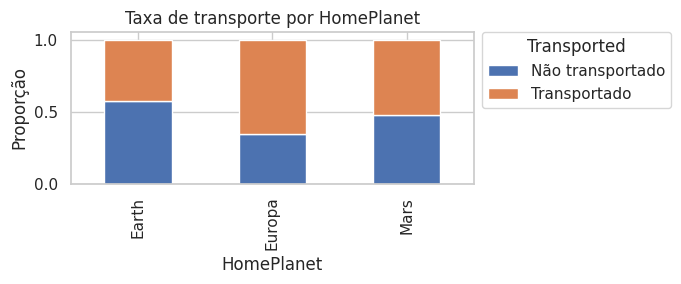

Gráfico com taxa de transporte por categoria: Destination


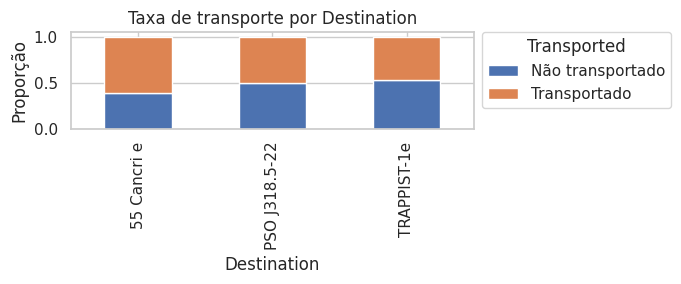

Gráfico com taxa de transporte por categoria: CryoSleep


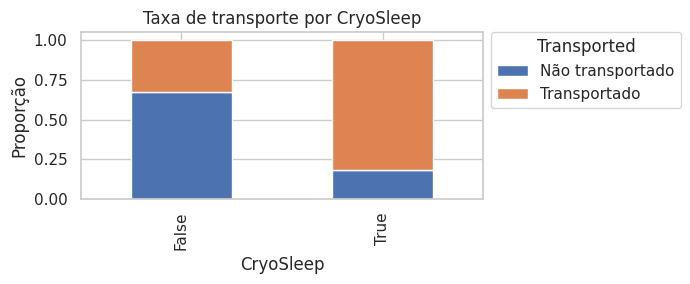

Gráfico com taxa de transporte por categoria: VIP


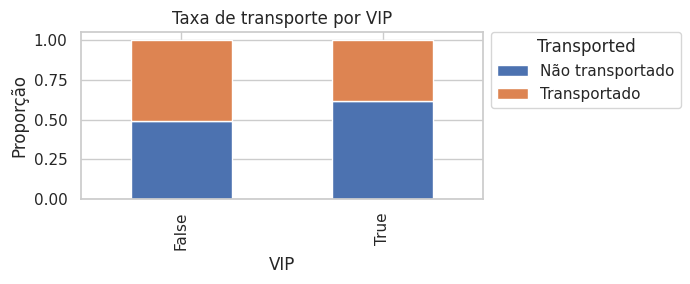

Gráfico com taxa de transporte por categoria: CabinDeck


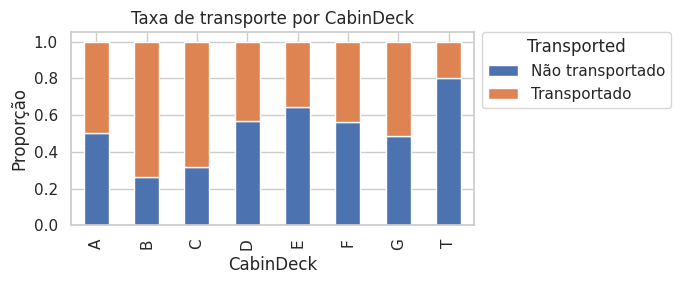

Gráfico com taxa de transporte por categoria: CabinSide


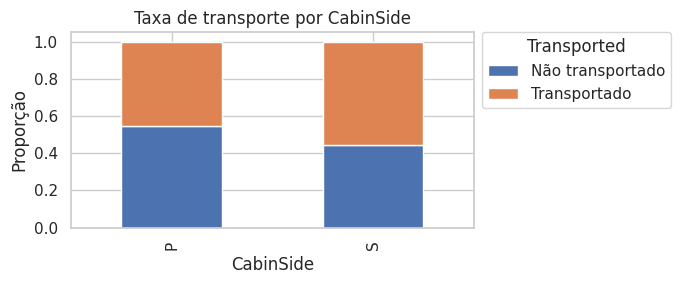

In [140]:
# Gráficos para cada categoria com taxa de transporte
for col in cat_cols:
    print(f"Gráfico com taxa de transporte por categoria: {col}")
    rate = pd.crosstab(eda[col], eda["Transported"], normalize="index")
    rate = rate.rename(columns={False: "Não transportado", True: "Transportado"})
    ax = rate.plot(
        kind="bar",
        stacked=True,
        figsize=(7, 3),
        title=f"Taxa de transporte por {col}"
    )
    ax.set_xlabel(col)
    ax.set_ylabel("Proporção")
    ax.legend(title="Transported", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    plt.tight_layout()
    plt.show()

### Grupo do passageiro

Como `PassengerGroup` também tem alta cardinalidade, a análise abaixo foca no tamanho dos grupos formados a partir de `PassengerId`. Isso ajuda a entender se passageiros que viajam em grupo apresentam padrões diferentes de transporte, sem tratar cada grupo como uma categoria isolada.


Tabela com distribuição dos tamanhos de PassengerGroup


,qtd_grupos,qtd_passageiros,transportado_pct
group_size,,,
1,4805,4805,45.24
2,841,1682,53.80
3,340,1020,59.31
4,103,412,64.08
5,53,265,59.25
6,29,174,61.49
7,33,231,54.11
8,13,104,39.42


Gráfico com taxa de transporte por tamanho de PassengerGroup


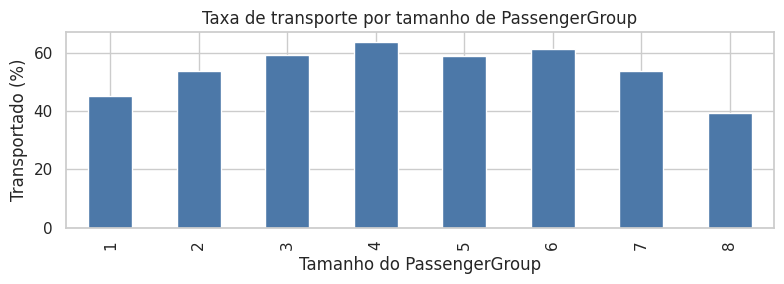

In [141]:
# Explora PassengerGroup pelo tamanho dos grupos
print("Tabela com distribuição dos tamanhos de PassengerGroup")
passenger_group_size = eda.groupby("PassengerGroup").size()
passenger_group_summary = (
    passenger_group_size.value_counts()
    .sort_index()
    .rename_axis("group_size")
    .to_frame("qtd_grupos")
)
passenger_group_summary["qtd_passageiros"] = passenger_group_summary.index * passenger_group_summary["qtd_grupos"]
passenger_group_summary["transportado_pct"] = (
    eda.assign(PassengerGroupSize=eda.groupby("PassengerGroup")["PassengerGroup"].transform("size"))
    .groupby("PassengerGroupSize")["Transported"]
    .mean()
    .mul(100)
    .round(2)
)
display(passenger_group_summary)

print("Gráfico com taxa de transporte por tamanho de PassengerGroup")
ax = passenger_group_summary["transportado_pct"].plot(
    kind="bar",
    figsize=(8, 3),
    title="Taxa de transporte por tamanho de PassengerGroup",
    color="#4C78A8",
)
ax.set_xlabel("Tamanho do PassengerGroup")
ax.set_ylabel("Transportado (%)")
plt.tight_layout()
plt.show()


## Transporte, criossono e gastos

Nas células de código abaixo, iremos separar duas ideias: gasto total mediano e presença de gasto positivo conhecido. A mediana de `TotalSpend` dos transportados irá aparecer como `0.0`, enquanto a dos não transportados irá aparecer como `907.0`; isso irá indicar que pelo menos metade dos transportados terá gasto total zero ou muito baixo, sem significar que todos não gastarão.

O que será observado:
- Percentual dos transportados que estarão em criossono.
- Percentual dos passageiros em criossono que terão algum gasto conhecido.
- Quantidade de registros com gastos ausentes, porque eles poderão esconder gasto não observado.

Resultados que serão destacados:
- Transportados em criossono: 58.12% (2483 de 4272 transportados com `CryoSleep` preenchido).
- Passageiros em criossono com algum gasto conhecido: 0.00% (0 de 3037).
- Transportados que gastarão algo: 34.38% (1505 de 4378).
- Mediana de `TotalSpend`: 907.0 para não transportados e 0.0 para transportados.
- Observação: existirão 347 passageiros em criossono com algum gasto ausente e sem gasto positivo registrado; por isso, a frase mais precisa será "nenhum gasto positivo conhecido".


In [142]:
# Análise de transporte, criossono e gastos
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

# Usa min_count=1 para não transformar linhas com todos os gastos ausentes em zero.
eda["TotalSpend"] = eda[spend_cols].sum(axis=1, min_count=1)
eda["SpentSomething"] = eda[spend_cols].gt(0).any(axis=1)
eda["HasMissingSpend"] = eda[spend_cols].isna().any(axis=1)

transported = eda["Transported"].eq(True)
cryosleep = eda["CryoSleep"].eq(True)
cryo_known = eda["CryoSleep"].notna()

transported_with_cryo_known = transported & cryo_known
pct_transported_in_cryo = cryosleep[transported_with_cryo_known].mean() * 100

pct_cryo_with_spend = eda.loc[cryosleep, "SpentSomething"].mean() * 100
pct_transported_with_spend = eda.loc[transported, "SpentSomething"].mean() * 100

focus = pd.DataFrame(
    [
        {
            "pergunta": "% dos transportados em criossono",
            "numerador": int((transported & cryosleep).sum()),
            "denominador": int(transported_with_cryo_known.sum()),
            "percentual": pct_transported_in_cryo,
        },
        {
            "pergunta": "% dos em criossono que gastaram algo",
            "numerador": int((cryosleep & eda["SpentSomething"]).sum()),
            "denominador": int(cryosleep.sum()),
            "percentual": pct_cryo_with_spend,
        },
        {
            "pergunta": "% dos transportados que gastaram algo",
            "numerador": int((transported & eda["SpentSomething"]).sum()),
            "denominador": int(transported.sum()),
            "percentual": pct_transported_with_spend,
        },
    ],
)

focus["percentual"] = focus["percentual"].round(2)

print("Perguntas foco")
display(focus)

print("Tabela de verificação: Transported x CryoSleep")
transport_cryo = pd.crosstab(
    eda["Transported"],
    eda["CryoSleep"],
    margins=True,
    margins_name="total",
)
display(transport_cryo)

print("Tabela de verificação: CryoSleep x gastou algo")
cryo_spend = pd.crosstab(
    eda["CryoSleep"],
    eda["SpentSomething"],
    margins=True,
    margins_name="total",
)
cryo_spend.columns = ["não_gastou", "gastou", "total"]
display(cryo_spend)

print("Registros com algum gasto ausente")
missing_spend = pd.DataFrame(
    {
        "grupo": ["transportados", "em_criossono", "em_criossono_sem_gasto_positivo"],
        "registros_com_gasto_ausente": [
            int((transported & eda["HasMissingSpend"]).sum()),
            int((cryosleep & eda["HasMissingSpend"]).sum()),
            int((cryosleep & ~eda["SpentSomething"] & eda["HasMissingSpend"]).sum()),
        ],
    }
)
display(missing_spend)


Perguntas foco


,pergunta,numerador,denominador,percentual
0,% dos transportados em criossono,2483,4272,58.12
1,% dos em criossono que gastaram algo,0,3037,0.00
2,% dos transportados que gastaram algo,1505,4378,34.38


Tabela de verificação: Transported x CryoSleep


CryoSleep,False,True,total
Transported,,,
False,3650,554,4204
True,1789,2483,4272
total,5439,3037,8476


Tabela de verificação: CryoSleep x gastou algo


,não_gastou,gastou,total
CryoSleep,,,
False,518,4921,5439
True,3037,0,3037
total,3555,4921,8476


Registros com algum gasto ausente


,grupo,registros_com_gasto_ausente
0,transportados,466
1,em_criossono,347
2,em_criossono_sem_gasto_positivo,347


### Mediana de gasto total por transporte

Na próxima célula de código, o gráfico irá materializar a mediana citada acima. A barra dos transportados irá ficar em `0`, indicando que pelo menos metade desse grupo terá gasto total zero registrado; a tabela seguinte irá conectar esse padrão ao `CryoSleep`.


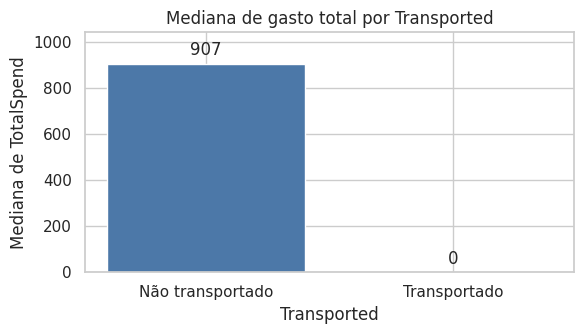

In [143]:
# Gráfico que irá ilustrar a mediana de gasto total por alvo
median_total_spend = (
    eda.groupby("Transported")["TotalSpend"]
    .median()
    .rename(index={False: "Não transportado", True: "Transportado"})
)

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(
    median_total_spend.index,
    median_total_spend.values,
    color=["#4C78A8", "#F58518"],
)

ax.set_title("Mediana de gasto total por Transported")
ax.set_xlabel("Transported")
ax.set_ylabel("Mediana de TotalSpend")
ax.bar_label(
    bars,
    labels=[f"{value:.0f}" for value in median_total_spend.values],
    padding=3,
)
ax.set_ylim(0, max(median_total_spend.max() * 1.15, 1))

plt.tight_layout()
plt.show()


In [144]:
# Tabela que irá relacionar gasto total com criossono
total_spend_by_cryo = (
    eda.groupby("CryoSleep", dropna=False)
    .agg(
        qtd_passageiros=("PassengerGroup", "size"),
        mediana_total_spend=("TotalSpend", "median"),
        média_total_spend=("TotalSpend", "mean"),
        pct_com_gasto=("SpentSomething", "mean"),
    )
    .reset_index()
)

total_spend_by_cryo["pct_com_gasto"] = (total_spend_by_cryo["pct_com_gasto"] * 100).round(2)
total_spend_by_cryo[["mediana_total_spend", "média_total_spend"]] = total_spend_by_cryo[
    ["mediana_total_spend", "média_total_spend"]
].round(2)

display(total_spend_by_cryo)


,CryoSleep,qtd_passageiros,mediana_total_spend,média_total_spend,pct_com_gasto
0,False,5439,1019.0,2248.30,90.48
1,True,3037,0.0,0.00,0.00
2,NaN,217,703.0,1368.43,54.84


## Correlações numéricas

Nas células de código abaixo, é calculada a correlação entre variáveis numéricas, incluindo o alvo `Transported` convertido para 0/1. A tabela ordena as variáveis pela intensidade absoluta da relação linear com o alvo, e o heatmap mostra também a relação entre as próprias variáveis numéricas.

O que será observado:
- Variáveis numéricas com maior correlação linear, em módulo, com `Transported`.
- Pares de variáveis muito correlacionadas entre si, que podem indicar redundância.
- Sinal da correlação: valores positivos e negativos indicam direções diferentes da relação linear.

Resultados que se destacam:
- `RoomService`, `Spa`, `VRDeck` e `TotalSpend` aparecem com as correlações negativas mais fortes em módulo, embora ainda moderadas/fracas.
- `Age`, `FoodCourt` e `ShoppingMall` aparecem com correlações mais fracas com `Transported`.
- `TotalSpend` tem correlação alta com algumas colunas de gasto, o que é esperado por ser uma soma dessas despesas.


Tabela com correlação das variáveis numéricas com o alvo


RoomService    -0.244611
Spa            -0.221131
VRDeck         -0.207075
TotalSpend     -0.199514
Age            -0.075026
PassengerNum    0.066390
FoodCourt       0.046566
ShoppingMall    0.010141
Name: Transported, dtype: float64

Gráfico heatmap com correlações entre variáveis numéricas


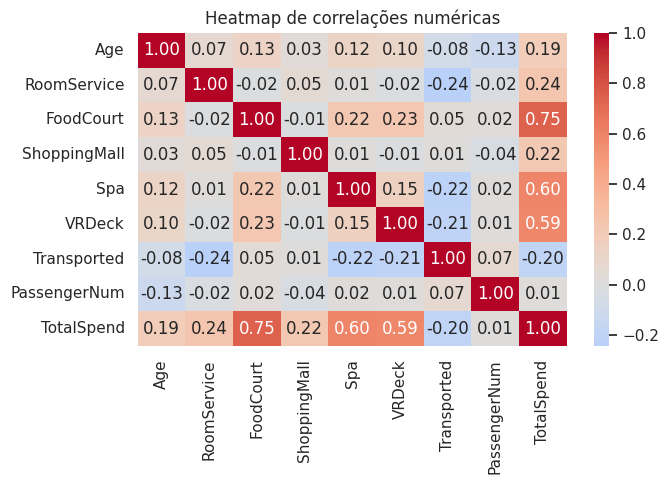

In [145]:
# Análise de correlação das variáveis numéricas com o alvo
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

if "TotalSpend" not in eda.columns:
    eda["TotalSpend"] = eda[spend_cols].sum(axis=1, min_count=1)

corr_data = eda.copy()
corr_data["Transported"] = corr_data["Transported"].astype(int)

num_cols = corr_data.select_dtypes(include="number").columns
corr = corr_data[num_cols].corr()

print("Tabela com correlação das variáveis numéricas com o alvo")
# Ordena a correlação com o alvo pela intensidade absoluta.
target_corr = corr["Transported"].drop("Transported")
target_corr = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index)
display(target_corr)

print("Gráfico heatmap com correlações entre variáveis numéricas")
# Heatmap das relações numéricas
plt.figure(figsize=(7, 5))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Heatmap de correlações numéricas")
plt.tight_layout()
plt.show()


## Síntese da EDA

A partir das tabelas e gráficos da EDA, os principais aprendizados são:

- O conjunto de treino tem 8693 registros e 14 colunas.
- O alvo `Transported` está praticamente balanceado: 50.36% transportados e 49.64% não transportados.
- Os valores ausentes são baixos e distribuídos entre várias colunas; a maior ausência está em `CryoSleep`, com 217 registros (2.50%).
- As colunas de gastos têm muitos zeros: entre 61.24% e 64.27% dos registros têm gasto zero em cada serviço individual.
- A idade tem mediana de 27 anos, com grupos transportados e não transportados muito próximos em idade mediana (26.0 vs. 27.0).
- `HomePlanet` apresenta uma diferença importante: Europa tem a maior taxa de transporte (65.88%), seguida por Mars (52.30%) e Earth (42.39%).
- `Destination` também mostra diferença: 55 Cancri e tem a maior taxa de transporte (61.00%), seguida por PSO J318.5-22 (50.38%) e TRAPPIST-1e (47.12%).
- `CryoSleep` é um dos sinais mais fortes da EDA: passageiros em criossono têm taxa de transporte de 81.76%, enquanto passageiros fora do criossono têm 32.89%.
- Passageiros VIP têm taxa de transporte menor (38.19%) do que passageiros não VIP (50.63%).
- `PassengerGroup` mostra que a maioria dos grupos tem apenas 1 passageiro (4805 grupos), mas grupos maiores, sobretudo de 2 a 7 passageiros, apresentam taxas de transporte mais altas do que grupos unitários; o pico aparece em grupos de 4 passageiros (64.08%), enquanto grupos de 8 passageiros caem para 39.42% e são raros.
- A analise de `PassengerGroup` x `HomePlanet` indica que poucos grupos misturam planetas, sugerindo que quase todos os grupos compartilham o mesmo planeta de origem.
- Em `CabinDeck`, os decks B e C têm as maiores taxas de transporte: B com 73.43% e C com 68.01%. O deck T tem taxa baixa (20.00%), mas tem apenas 5 registros, então esse resultado pede cautela.
- Em `CabinSide`, o lado S tem maior taxa de transporte (55.50%) do que o lado P (45.13%).
- A mediana de `TotalSpend` é 907.0 para não transportados e 0.0 para transportados. Isso não significa que nenhum transportado gaste algo; 1505 transportados têm algum gasto positivo conhecido (34.38%).
- A relação entre gasto e criossono fica bem clara: passageiros em `CryoSleep=True` têm mediana de `TotalSpend` igual a 0.0 e 0.00% com gasto positivo conhecido; passageiros em `CryoSleep=False` têm mediana de 1019.0 e 90.48% com algum gasto.
- Entre os transportados com `CryoSleep` preenchido, 58.12% estão em criossono.
- As correlações numéricas com `Transported` são fracas a moderadas: `RoomService` (-0.245), `Spa` (-0.221), `VRDeck` (-0.207) e `TotalSpend` (-0.200) são as mais fortes em módulo, enquanto `Age` (-0.075), `FoodCourt` (0.047) e `ShoppingMall` (0.010) são muito fracas.


# Pré-processamento

Nesta seção, estruturamos o pré-processamento pensando em uma árvore de decisão com `Pipeline` do scikit-learn.
Aqui, aplicamos a separação de `PassengerId` e `Cabin` diretamente em `train` e `test` (apenas nesta seção), removemos `Name` e `CabinNum`, e separamos `X` e `y`.
Em seguida, montamos um `ColumnTransformer` com `KNNImputer` para valores ausentes numéricos e binários, `StandardScaler` (z-score) para variáveis numéricas e codificações adequadas para variáveis categóricas e binárias.
Para variáveis categóricas, os valores ausentes são tratados como uma categoria explícita pelo `OneHotEncoder`.
Todo o ajuste é feito apenas no treino, evitando data-leak ao transformar o conjunto de teste.


In [146]:
# Conjunto base para modelagem
train = split_cabin_passenger(train)
test = split_cabin_passenger(test)

drop_cols = ["Name", "CabinNum"]
train = train.drop(columns=drop_cols, errors="ignore")
test = test.drop(columns=drop_cols, errors="ignore")

target = "Transported"
X = train.drop(columns=[target])
y = train[target].astype(int)

## Legenda das variáveis binárias (0/1)

- `CabinSide`: P → 0, S → 1
- `CryoSleep`: False → 0, True → 1
- `VIP`: False → 0, True → 1

Além dessas transformações, aplicaremos One Hot Encoding em `CabinDeck`, `Destination`, `HomePlanet` e `PassengerGroup` para preservar essas categorias sem impor ordem numérica.

In [147]:
# Definição das colunas para o pré-processamento
categorical_ohe = ["CabinDeck", "Destination", "HomePlanet", "PassengerGroup"]
binary_cols = ["CabinSide", "CryoSleep", "VIP"]

numeric_cols = [
    col
    for col in X.columns
    if col not in categorical_ohe + binary_cols
    and pd.api.types.is_numeric_dtype(X[col])
].copy()

binary_categories = [
    ["P", "S"],
    [False, True],
    [False, True],
]

def round_binary(values):
    return np.clip(np.rint(values), 0, 1).astype(int)

binary_pipeline = Pipeline(
    steps=[
        # Encoder: mapeia categorias binarias para 0/1 seguindo binary_categories.
        ("encoder", OrdinalEncoder(categories=binary_categories, handle_unknown="use_encoded_value", unknown_value=np.nan)),
        ("imputer", KNNImputer(n_neighbors=5)),
        # Rounder: apos imputacao KNN, garante saida binaria (0/1).
        ("rounder", FunctionTransformer(round_binary, feature_names_out="one-to-one")),
    ]
)

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", KNNImputer(n_neighbors=5)),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("bin", binary_pipeline, binary_cols),
        ("cat", categorical_pipeline, categorical_ohe),
    ],
    remainder="drop",
)

# Modelos

Nesta etapa, treinamos e avaliamos uma árvore de decisão usando o `Pipeline` com o pré-processamento definido acima.

In [148]:
# Treinamento e avaliação com árvore de decisão (cross-validation)
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

tree_model = DecisionTreeClassifier(random_state=42)
tree_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", tree_model),
    ]
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}

cv_results = cross_validate(
    tree_pipeline,
    X,
    y,
    cv=skf,
    scoring=scoring,
    n_jobs=-1,
)

cv_summary = pd.DataFrame({metric: cv_results[f"test_{metric}"] for metric in scoring})
print("Médias e desvios por métrica (10 folds)")
display(cv_summary.agg(["mean", "std"]).round(4))

Médias e desvios por métrica (10 folds)


,accuracy,precision,recall,f1
mean,0.7703,0.7700,0.7757,0.7728
std,0.0189,0.0193,0.0213,0.0189


In [149]:
# Treinamento final no treino completo e previsoes no teste (sem rotulos)
final_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42)),
    ]
)

final_pipeline.fit(X, y)

raw_test = pd.read_csv("./data/test.csv")
test_features = split_cabin_passenger(raw_test)
test_features = test_features.drop(columns=drop_cols, errors="ignore")

test_pred = final_pipeline.predict(test_features)

submission = pd.DataFrame(
    {
        "PassengerId": raw_test["PassengerId"],
        "Transported": test_pred.astype(bool),
    }
)

print("Previa do arquivo de submissao")
display(submission.head())

submission.to_csv("submission.csv", index=False)

Previa do arquivo de submissao


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


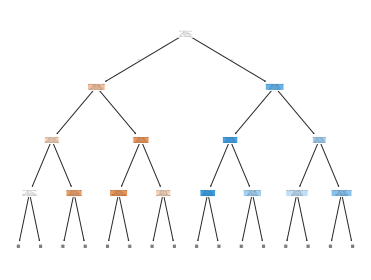

In [ ]:
set_matplotlib_formats("svg")

tree.plot_tree(
    final_pipeline.named_steps["model"],
    feature_names=final_pipeline.named_steps["preprocess"].get_feature_names_out(),
    class_names=["Nao transportado", "Transportado"],
    filled=True,
    max_depth=10,
 )
plt.show()

Matriz de confusao (holdout 20%)


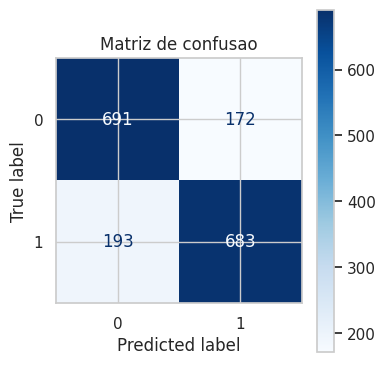

Curva ROC (holdout 20%)


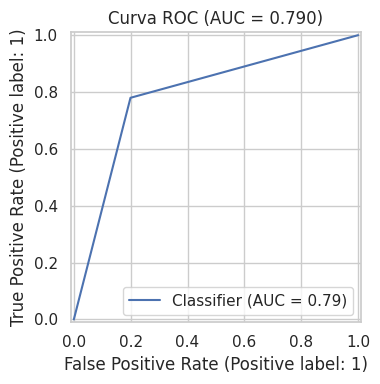

In [151]:
# Avaliacao em holdout para matriz de confusao e curva ROC
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

holdout_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42)),
    ]
)

holdout_pipeline.fit(X_train, y_train)

y_pred = holdout_pipeline.predict(X_val)

print("Matriz de confusao (holdout 20%)")
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, ax=ax, cmap="Blues")
ax.set_title("Matriz de confusao")
plt.tight_layout()
plt.show()

y_score = holdout_pipeline.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_score)

print("Curva ROC (holdout 20%)")
fig, ax = plt.subplots(figsize=(5, 4))
RocCurveDisplay.from_predictions(y_val, y_score, ax=ax)
ax.set_title(f"Curva ROC (AUC = {auc:.3f})")
plt.tight_layout()
plt.show()